In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
with open("dataset_exercicio_2.csv", "r") as f:
    linhas = f.readlines()

dados = []
for linha in linhas:
    linha = linha.strip().strip('|')
    if '---' in linha:
        continue
    partes = [p.strip() for p in linha.split('|')]
    try:
        dados.append([float(p) for p in partes])
    except ValueError:
        continue

dataset = np.array(dados)

print(dataset)

[[ 1.   3. ]
 [ 2.   3.5]
 [ 3.   4. ]
 [ 4.   4.5]
 [ 5.   5. ]
 [ 6.   5.8]
 [ 7.   6.2]
 [ 8.   6.8]
 [ 9.   7.4]
 [10.   8. ]
 [11.   8.5]
 [12.   9.2]
 [13.   9.6]
 [14.  10.2]
 [15.  10.8]
 [16.  11.3]
 [17.  12. ]
 [18.  12.5]
 [19.  13.2]
 [20.  14. ]]


In [5]:
X = dataset[:, 0]
y = dataset[:, 1]
n = len(X)

print("X:", X)
print("y:", y)

print("\n Número de amostras: ", X.shape[0])

X: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
y: [ 3.   3.5  4.   4.5  5.   5.8  6.2  6.8  7.4  8.   8.5  9.2  9.6 10.2
 10.8 11.3 12.  12.5 13.2 14. ]

 Número de amostras:  20


Média de X: 10.5
Média de y: 8.275

Intercepto (a): 2.2663
Inclinação (b): 0.5723

Valores previstos: [ 2.83857143  3.41082707  3.98308271  4.55533835  5.12759398  5.69984962
  6.27210526  6.8443609   7.41661654  7.98887218  8.56112782  9.13338346
  9.7056391  10.27789474 10.85015038 11.42240602 11.99466165 12.56691729
 13.13917293 13.71142857]

Cálculo do Coeficiente de Pearson: 0.9995

Cálculo de Determinação: 99.9057


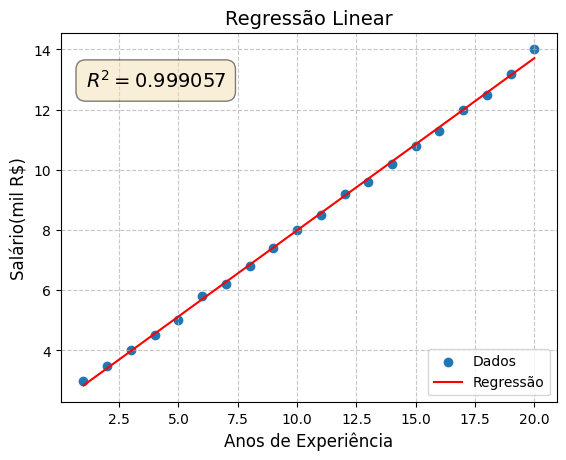

In [6]:
x_mean = np.mean(X)
y_mean = np.mean(y)

print("Média de X:", x_mean)
print("Média de y:", y_mean)

b, a = np.polyfit(X, y, 1)
print(f"\nIntercepto (a): {a:.4f}")
print(f"Inclinação (b): {b:.4f}")

y_pred = a + b * X
print(f"\nValores previstos: {y_pred}")

coef_pearson = np.corrcoef(X, y)[0, 1]
print(f"\nCálculo do Coeficiente de Pearson: {coef_pearson:.4f}")

det_quadrado = coef_pearson ** 2
print(f"\nCálculo de Determinação: {det_quadrado * 100:.4f}")

plt.scatter(X, y, label="Dados")
plt.plot(X, y_pred, color="red", label="Regressão")
plt.title("Regressão Linear", fontsize=14)
plt.xlabel("Anos de Experiência", fontsize=12)
plt.ylabel("Salário(mil R$)", fontsize=12)
plt.text(0.05, 0.9, f'$R^2 = {det_quadrado:4f}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### a- O modelo mostra uma relação linear entre anos de experiência e salário? O gráfico sugere uma tendência clara?

R: Sim, o modelo mostra uma relação linear bastante forte entre anos de experiência e salário. O gráfico apresenta uma tendência crescente quase perfeita, indicando que, conforme os anos de experiência aumentam, o salário também cresce de forma consistente. Isso é reforçado pelo alto grau de linearidade dos dados.

### b- Qual é a interpretação do coeficiente angular nesse caso (quanto aumenta o salário a cada ano de experiência)?

R: O coeficiente angular é aproximadamente b ≈ 0,58. Isso significa que, em média, o salário aumenta cerca de 0,58 mil reais (R$ 580) a cada ano adicional de experiência.

### c- Se um funcionário tiver 25 anos de experiência, qual salário seria previsto pelo modelo? Essa previsão faz sentido na prática?

R: Usando a equação da reta y=a+bx:

y≈2,25+0,58×25 y≈2,25+14,5=16,75

Portanto, o salário previsto é aproximadamente 16,75 mil reais.

Essa previsão pode ser razoável matematicamente, mas deve ser analisada com cautela, pois 25 anos está fora do intervalo dos dados (1 a 20 anos). Em situações reais, podem ocorrer variações na progressão salarial que o modelo linear não captura.

### d- Há sinais de que a progressão salarial não é perfeitamente linear (ex.: ganhos maiores após certo tempo)? Como isso poderia afetar a escolha do modelo?

R: Não há indícios significativos de não linearidade nos dados. A relação entre anos de experiência e salário é praticamente linear, o que é confirmado tanto pelo gráfico quanto pelo alto valor de R2, que indica um ajuste quase perfeito da regressão linear. As pequenas variações observadas são normais em dados reais e não caracterizam um padrão não linear. Portanto, o modelo linear é adequado para representar esse conjunto de dados, não sendo necessário o uso de modelos mais complexos.

### e- Quais limitações você enxerga ao usar apenas anos de experiência como variável explicativa para o salário?

R: Usar apenas anos de experiência simplifica demais o problema, pois o salário depende de vários outros fatores, como nível de escolaridade, cargo, área de atuação, desempenho, tamanho da empresa, localização e habilidades individuais. Portanto, um modelo mais realista deveria incluir múltiplas variáveis para explicar melhor as variações salariais.